# SA.1 – Análisis Supervisado: Regresión
## Dataset: `articulos_ml.csv`
## Alumno: Santiago González Aguirre
## Fecha: 2026-08-19
---

## 1. Justificación del Algoritmo

Se seleccionó **Random Forest Regressor** por las siguientes razones:

- El dataset `articulos_ml.csv` presenta **valores atípicos extremos** en la variable objetivo (`# Shares`), con valores que oscilan entre 0 y 200,000. Random Forest es robusto ante outliers al promediar múltiples árboles.
- El conjunto de datos contiene **valores faltantes** y **mezcla de variables numéricas** (Word count, # Links, etc.). Los árboles de decisión base de Random Forest toleran bien esta heterogeneidad.
- La relación entre las características y el número de shares **no es lineal** (no tiene sentido asumir que más palabras = más shares de forma proporcional). Random Forest captura relaciones no lineales sin transformaciones explícitas.
- Con un dataset pequeño (~161 registros), Random Forest reduce el sobreajuste mediante *bagging*, a diferencia de un árbol simple.

**Alternativas descartadas:** Regresión Lineal (asume linealidad y es sensible a outliers), SVR (requiere escalado y ajuste de kernel).

## 2. Paso 1 – Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib

# Estilo visual
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'axes.edgecolor': '#0f3460',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#e0e0e0',
    'ytick.color': '#e0e0e0',
    'text.color': '#e0e0e0',
    'grid.color': '#0f3460',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans'
})

PALETTE_MAIN  = '#e94560'
PALETTE_SEC   = '#0f3460'
PALETTE_ACC   = '#533483'
PALETTE_GOOD  = '#4caf82'

print('Librerías cargadas correctamente ✓')
print(f'Versión pandas: {pd.__version__}')

Librerías cargadas correctamente ✓
Versión pandas: 3.0.3


## 3. Paso 2 – Carga y exploración del dataset

In [2]:
# Carga del dataset
df = pd.read_csv('articulos_ml.csv')

print('=== INFORMACIÓN GENERAL ===')
print(f'Forma del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'\nColumnas: {list(df.columns)}')
print('\n=== PRIMERAS 5 FILAS ===')
df.head()

=== INFORMACIÓN GENERAL ===
Forma del dataset: 161 filas × 8 columnas

Columnas: ['Title', 'url', 'Word count', '# of Links', '# of comments', '# Images video', 'Elapsed days', '# Shares']

=== PRIMERAS 5 FILAS ===


,Title,url,Word count,# of Links,# of comments,# Images video,Elapsed days,# Shares
0,What is Machine Learning and how do we use it ...,https://blog.signals.network/what-is-machine-l...,1888,1,2.0,2,34,200000
1,10 Companies Using Machine Learning in Cool Ways,NaN,1742,9,NaN,9,5,25000
2,How Artificial Intelligence Is Revolutionizing...,NaN,962,6,0.0,1,10,42000
3,Dbrain and the Blockchain of Artificial Intell...,NaN,1221,3,NaN,2,68,200000
4,Nasa finds entire solar system filled with eig...,NaN,2039,1,104.0,4,131,200000


In [3]:
print('=== TIPOS DE DATOS Y VALORES NULOS ===')
info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'No Nulos': df.count(),
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info_df)
print('\n=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe()

=== TIPOS DE DATOS Y VALORES NULOS ===
                   Tipo  No Nulos  Nulos  % Nulos
Title               str       161      0     0.00
url                 str       122     39    24.22
Word count        int64       161      0     0.00
# of Links        int64       161      0     0.00
# of comments   float64       129     32    19.88
# Images video    int64       161      0     0.00
Elapsed days      int64       161      0     0.00
# Shares          int64       161      0     0.00

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Word count,# of Links,# of comments,# Images video,Elapsed days,# Shares
count,161.000000,161.000000,129.000000,161.000000,161.000000,161.000000
mean,1808.260870,9.739130,8.782946,3.670807,98.124224,27948.347826
std,1141.919385,47.271625,13.142822,3.418290,114.337535,43408.006839
min,250.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,990.000000,3.000000,2.000000,1.000000,31.000000,2800.000000
50%,1674.000000,5.000000,6.000000,3.000000,62.000000,16458.000000
75%,2369.000000,7.000000,12.000000,5.000000,124.000000,35691.000000
max,8401.000000,600.000000,104.000000,22.000000,1002.000000,350000.000000


## 4. Paso 3 – Preprocesamiento

In [4]:
# Eliminar columnas no numéricas / identificadores
df_clean = df.drop(columns=['Title', 'url'], errors='ignore')

# Convertir columnas a numérico (fuerza errores a NaN)
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Reemplazar NaN con la mediana de cada columna (robusto ante outliers)
for col in df_clean.columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

print('Valores nulos tras imputación:', df_clean.isnull().sum().sum())
print('Shape final:', df_clean.shape)
df_clean.head()

Valores nulos tras imputación: 32
Shape final: (161, 6)


,Word count,# of Links,# of comments,# Images video,Elapsed days,# Shares
0,1888,1,2.0,2,34,200000
1,1742,9,NaN,9,5,25000
2,962,6,0.0,1,10,42000
3,1221,3,NaN,2,68,200000
4,2039,1,104.0,4,131,200000


## 5. Paso 4 – Gráfica de dispersión del comportamiento de datos

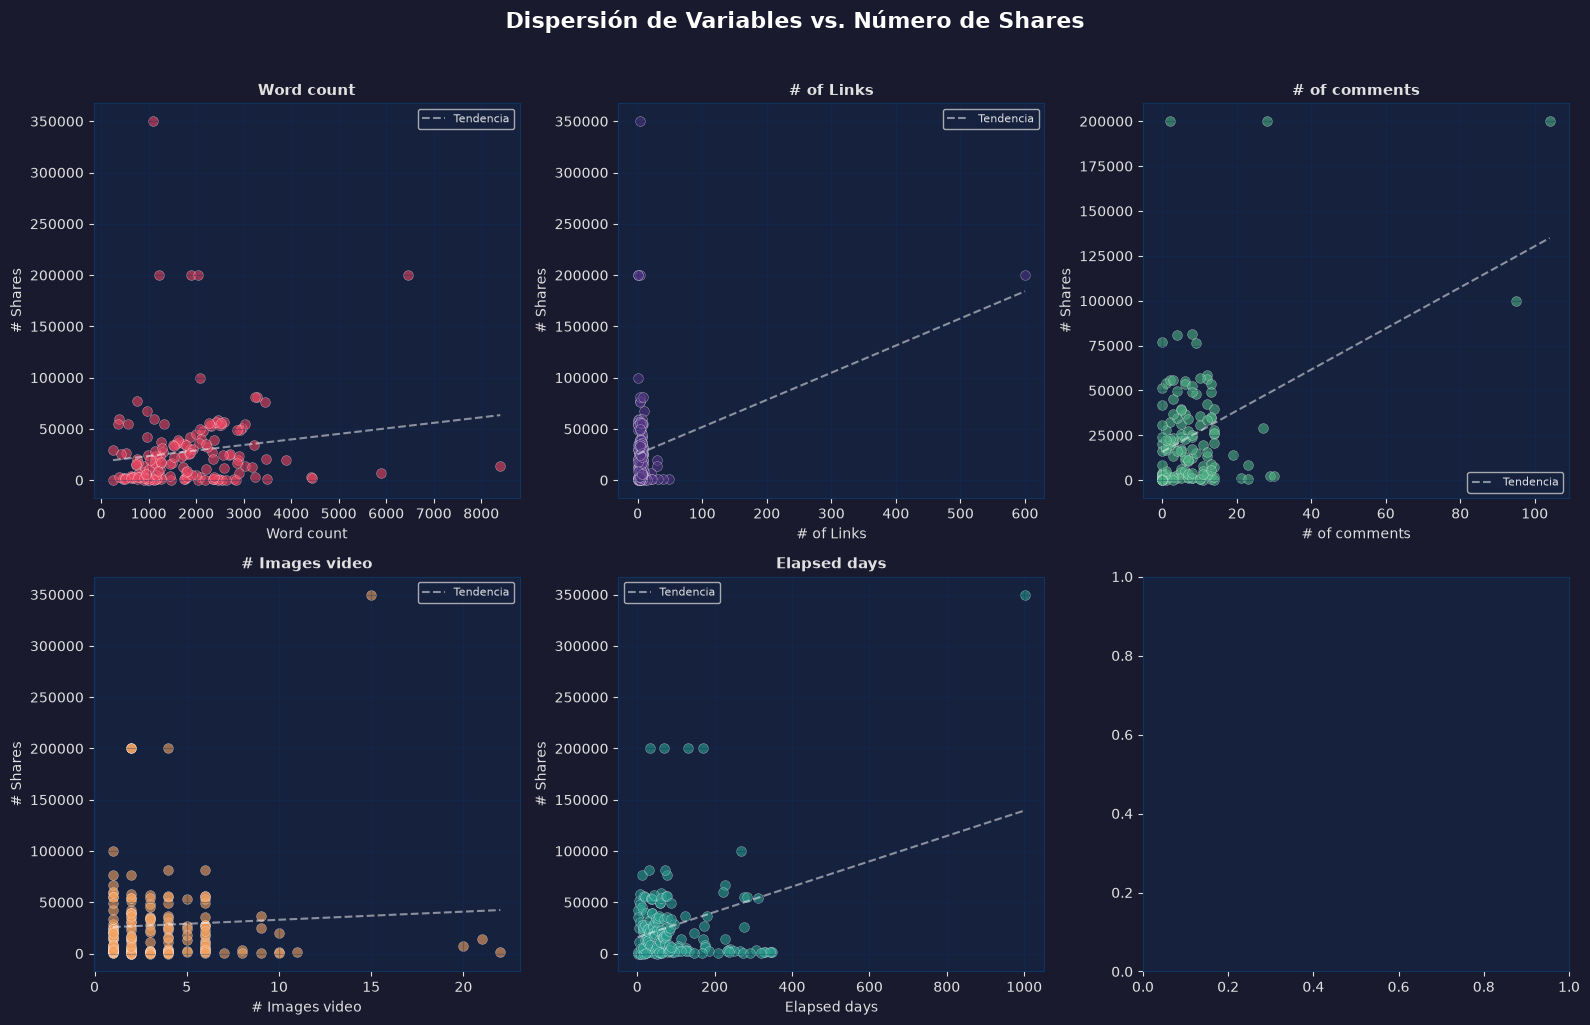

Gráfica guardada como SA1_dispersion.png


In [6]:
feature_cols = [c for c in df_clean.columns if c != '# Shares']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Dispersión de Variables vs. Número de Shares', fontsize=16, fontweight='bold', color='white', y=1.02)
axes = axes.flatten()

colors = [PALETTE_MAIN, PALETTE_ACC, PALETTE_GOOD, '#f4a261', '#2a9d8f', '#e9c46a']

for i, col in enumerate(feature_cols[:6]):
    ax = axes[i]
    x_vals = df_clean[col]
    y_vals = df_clean['# Shares']

    ax.scatter(x_vals, y_vals, alpha=0.6, color=colors[i],
               edgecolors='white', linewidths=0.3, s=50)

    # Línea de tendencia solo si la columna tiene varianza suficiente
    if x_vals.std() > 0 and x_vals.nunique() > 2:
        try:
            # Quitar NaN/inf antes de polyfit
            mask = np.isfinite(x_vals) & np.isfinite(y_vals)
            z = np.polyfit(x_vals[mask], y_vals[mask], 1)
            p = np.poly1d(z)
            x_line = np.linspace(x_vals[mask].min(), x_vals[mask].max(), 100)
            ax.plot(x_line, p(x_line), '--', color='white', alpha=0.5,
                    linewidth=1.5, label='Tendencia')
        except Exception:
            pass  # Si aún falla, omitir la línea sin romper la gráfica

    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('# Shares', fontsize=10)
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('SA1_dispersion.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Gráfica guardada como SA1_dispersion.png')

## 6. Paso 5 – División del dataset y entrenamiento base

In [7]:
# Variable objetivo
X = df_clean.drop(columns=['# Shares'])
y = df_clean['# Shares']

# División 80/20 con semilla fija para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')

# Modelo base
rf_base = RandomForestRegressor(random_state=42)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)

mae_b  = mean_absolute_error(y_test, y_pred_base)
rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_b   = r2_score(y_test, y_pred_base)

print(f'\n--- Modelo BASE (sin optimizar) ---')
print(f'MAE:  {mae_b:,.0f} shares')
print(f'RMSE: {rmse_b:,.0f} shares')
print(f'R²:   {r2_b:.4f}')

Entrenamiento: 128 muestras
Prueba:        33 muestras

--- Modelo BASE (sin optimizar) ---
MAE:  22,284 shares
RMSE: 28,164 shares
R²:   -1.0966


## 7. Paso 6 – Búsqueda de hiperparámetros (GridSearchCV)

In [8]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

print('Ejecutando GridSearchCV (esto puede tomar ~1-2 minutos)...')

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f'\n✓ Mejores hiperparámetros encontrados:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\n  R² de validación cruzada: {grid_search.best_score_:.4f}')

Ejecutando GridSearchCV (esto puede tomar ~1-2 minutos)...

✓ Mejores hiperparámetros encontrados:
  max_depth: 5
  max_features: sqrt
  min_samples_split: 10
  n_estimators: 100

  R² de validación cruzada: -0.1504


## 8. Paso 7 – Evaluación del modelo optimizado

In [9]:
# Modelo optimizado
rf_opt = grid_search.best_estimator_
y_pred_opt = rf_opt.predict(X_test)

mae_o  = mean_absolute_error(y_test, y_pred_opt)
rmse_o = np.sqrt(mean_squared_error(y_test, y_pred_opt))
r2_o   = r2_score(y_test, y_pred_opt)

# Validación cruzada del modelo optimizado
cv_scores = cross_val_score(rf_opt, X, y, cv=5, scoring='r2')

print(f'--- Modelo OPTIMIZADO ---')
print(f'MAE:            {mae_o:,.0f} shares')
print(f'RMSE:           {rmse_o:,.0f} shares')
print(f'R²:             {r2_o:.4f}')
print(f'R² CV (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

print(f'\n--- Comparativa BASE vs OPTIMIZADO ---')
print(f'{'Métrica':<12} {'Base':>12} {'Optimizado':>12} {'Mejora':>10}')
print('-' * 50)
print(f'{'MAE':<12} {mae_b:>12,.0f} {mae_o:>12,.0f} {(mae_b-mae_o)/mae_b*100:>9.1f}%')
print(f'{'RMSE':<12} {rmse_b:>12,.0f} {rmse_o:>12,.0f} {(rmse_b-rmse_o)/rmse_b*100:>9.1f}%')
print(f'{'R²':<12} {r2_b:>12.4f} {r2_o:>12.4f} {(r2_o-r2_b)*100:>9.2f}pp')

--- Modelo OPTIMIZADO ---
MAE:            21,352 shares
RMSE:           29,988 shares
R²:             -1.3768
R² CV (5-fold): -70.9210 ± 141.4289

--- Comparativa BASE vs OPTIMIZADO ---
Métrica              Base   Optimizado     Mejora
--------------------------------------------------
MAE                22,284       21,352       4.2%
RMSE               28,164       29,988      -6.5%
R²                -1.0966      -1.3768    -28.03pp


## 9. Paso 8 – Gráfica comparativa: Valores Reales vs Predichos

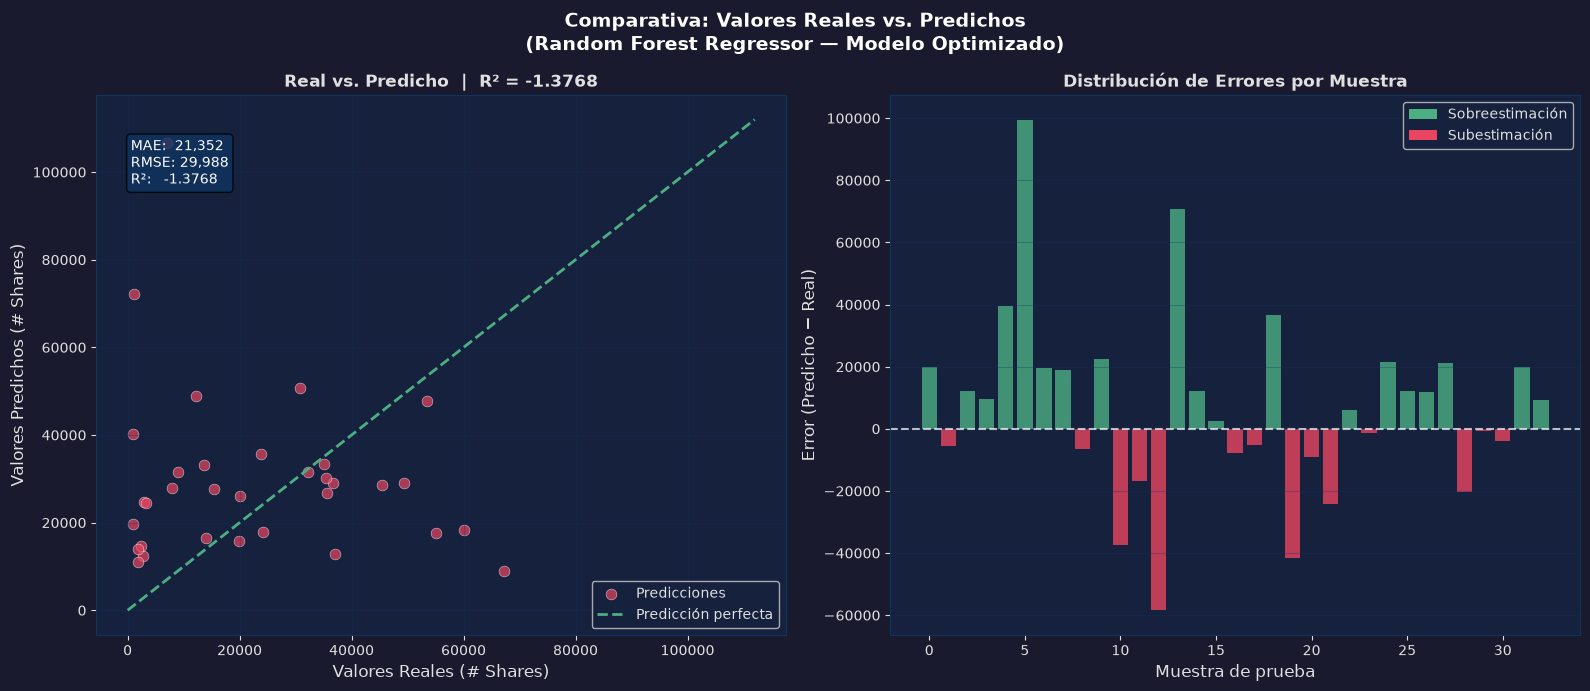

Gráfica guardada como SA1_real_vs_predicho.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Comparativa: Valores Reales vs. Predichos\n(Random Forest Regressor — Modelo Optimizado)', 
             fontsize=14, fontweight='bold', color='white')

# --- Gráfica izquierda: Scatter Real vs Predicho ---
ax1 = axes[0]
ax1.scatter(y_test, y_pred_opt, alpha=0.7, color=PALETTE_MAIN, edgecolors='white', linewidths=0.4, s=60, label='Predicciones')
lim = max(y_test.max(), y_pred_opt.max()) * 1.05
ax1.plot([0, lim], [0, lim], '--', color=PALETTE_GOOD, linewidth=2, label='Predicción perfecta')
ax1.set_xlabel('Valores Reales (# Shares)', fontsize=12)
ax1.set_ylabel('Valores Predichos (# Shares)', fontsize=12)
ax1.set_title(f'Real vs. Predicho  |  R² = {r2_o:.4f}', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Anotaciones de métricas
ax1.text(0.05, 0.92, f'MAE:  {mae_o:,.0f}\nRMSE: {rmse_o:,.0f}\nR²:   {r2_o:.4f}',
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='#0f3460', alpha=0.8), color='white')

# --- Gráfica derecha: Error por muestra ---
ax2 = axes[1]
indices = range(len(y_test))
errors = y_pred_opt - y_test.values
colors_err = [PALETTE_GOOD if e >= 0 else PALETTE_MAIN for e in errors]
bars = ax2.bar(indices, errors, color=colors_err, alpha=0.8, edgecolor='none')
ax2.axhline(y=0, color='white', linewidth=1.5, linestyle='--', alpha=0.7)
ax2.set_xlabel('Muestra de prueba', fontsize=12)
ax2.set_ylabel('Error (Predicho − Real)', fontsize=12)
ax2.set_title('Distribución de Errores por Muestra', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE_GOOD, label='Sobreestimación'),
    Patch(facecolor=PALETTE_MAIN, label='Subestimación')
]
ax2.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig('SA1_real_vs_predicho.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Gráfica guardada como SA1_real_vs_predicho.png')

## 10. Paso 9 – Importancia de variables

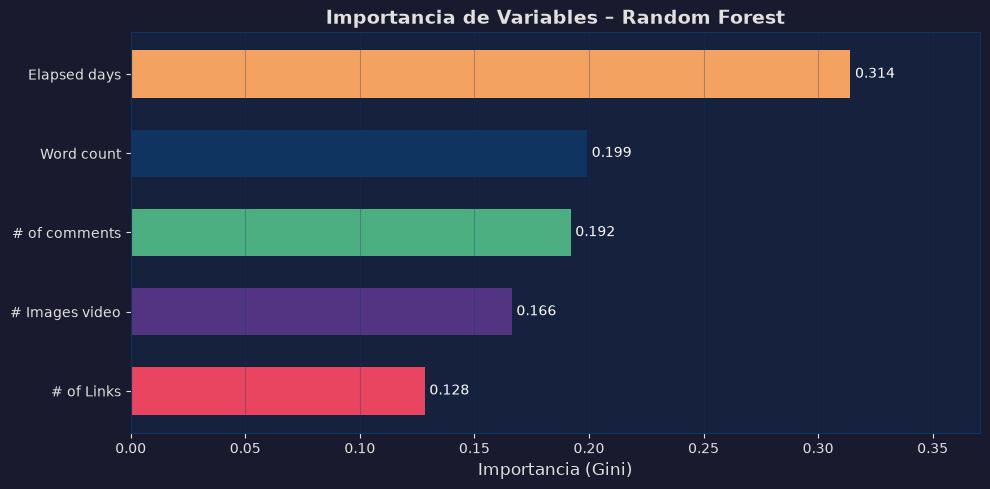

Gráfica guardada como SA1_importancia.png


In [11]:
importances = rf_opt.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#1a1a2e')

bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=[PALETTE_MAIN, PALETTE_ACC, PALETTE_GOOD, PALETTE_SEC, '#f4a261', '#e9c46a'][:len(feat_df)],
               edgecolor='none', height=0.6)

for bar, val in zip(bars, feat_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, color='white')

ax.set_xlabel('Importancia (Gini)', fontsize=12)
ax.set_title('Importancia de Variables – Random Forest', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(0, feat_df['Importance'].max() * 1.18)

plt.tight_layout()
plt.savefig('SA1_importancia.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Gráfica guardada como SA1_importancia.png')

## 11. Paso 10 – Guardar el modelo

In [12]:
joblib.dump(rf_opt, 'SA1_modelo_regresion_rf.pkl')
print('✓ Modelo guardado como: SA1_modelo_regresion_rf.pkl')
print(f'  Tamaño aprox.: {round(__import__("os").path.getsize("SA1_modelo_regresion_rf.pkl")/1024, 1)} KB')

# Resumen final
print('\n=== RESUMEN FINAL ===')
print(f'Algoritmo:         Random Forest Regressor')
print(f'Mejores params:    {grid_search.best_params_}')
print(f'MAE  (test):       {mae_o:,.0f} shares')
print(f'RMSE (test):       {rmse_o:,.0f} shares')
print(f'R²   (test):       {r2_o:.4f}')
print(f'R²   (CV 5-fold):  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

✓ Modelo guardado como: SA1_modelo_regresion_rf.pkl
  Tamaño aprox.: 157.2 KB

=== RESUMEN FINAL ===
Algoritmo:         Random Forest Regressor
Mejores params:    {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
MAE  (test):       21,352 shares
RMSE (test):       29,988 shares
R²   (test):       -1.3768
R²   (CV 5-fold):  -70.9210 ± 141.4289
